# End to end optimised forecast demo
Here we load the trained Aardvark Weather model and produce end-to-end finetuned forecasts at one day lead time for temperature and windspeed. 

## Phase 0 Walkthrough Notes

This notebook shows the end-to-end fine-tuned station forecast path. The local copy skips inference unless CUDA and downloaded end-to-end weights are present.

In [1]:
import pickle

import numpy as np
from matplotlib import pyplot as plt
import matplotlib
import torch

from weather_research.aardvark_local import (
    LocalConvCNPWeatherE2E,
    move_tensors_to_device,
    redirect_cuda_to_device,
)
from weather_research.phase0 import (
    AARDVARK_DATA_DIR,
    AARDVARK_TRAINED_MODELS_DIR,
    choose_torch_device,
    require_path,
    load_torch_pickle_cpu,
)

matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"


Check a GPU is available

In [2]:
DEVICE = choose_torch_device()
HAS_AARDVARK_WEIGHTS = AARDVARK_TRAINED_MODELS_DIR.exists()
CAN_RUN_AARDVARK_MODEL = HAS_AARDVARK_WEIGHTS
print(f"Local torch device preference: {DEVICE}")
print(f"Aardvark trained weights present: {HAS_AARDVARK_WEIGHTS}")
if not CAN_RUN_AARDVARK_MODEL:
    print("Aardvark weights are missing, so end-to-end inference cannot run.")


Local torch device preference: mps
Aardvark trained weights present: True


## Generate predictions

Load the sample data (for a detailed analysis and visualisation of the contents of this dataset see data_demo.ipynb)

In [3]:
sample_data_path = require_path(AARDVARK_DATA_DIR / "sample_data_final.pkl", "Aardvark sample data")
data = load_torch_pickle_cpu(sample_data_path)
print(f"Loaded {sample_data_path}")
print(data.keys())
if CAN_RUN_AARDVARK_MODEL:
    data = move_tensors_to_device(data, DEVICE)
    print(f"Moved sample tensors to {DEVICE}")


Loaded /Users/ewencheung/Documents/GitHub/Weather-Research/Reference-Repo-aardvark-weather-public-main/data/sample_data_final.pkl
dict_keys(['assimilation', 'forecast', 'downscaling', 'y_target'])
Moved sample tensors to mps


In [4]:
# Aardvark sample structure check: this runs locally without model weights.
print("Assimilation sources:", len(data["assimilation"]))
print("Forecast keys:", data["forecast"].keys())
print("Downscaling keys:", data["downscaling"].keys())
for key in ["hirs_current", "amsua_current", "amsub_current", "iasi_current", "ascat_current"]:
    value = data["assimilation"][key]
    print(f"{key}: shape={tuple(value.shape)}, device={value.device}, dtype={value.dtype}")
print("forecast y_context:", tuple(data["forecast"]["y_context"].shape))
print("downscaling x_target:", tuple(data["downscaling"]["x_target"].shape))


Assimilation sources: 26
Forecast keys: dict_keys(['y_context', 'y_target', 'lt'])
Downscaling keys: dict_keys(['x_target', 'alt_target', 'y_target', 'y_context', 'x_context', 'aux_time', 'lt'])
hirs_current: shape=(1, 360, 181, 26), device=mps:0, dtype=torch.float32
amsua_current: shape=(1, 180, 360, 13), device=mps:0, dtype=torch.float32
amsub_current: shape=(1, 360, 181, 12), device=mps:0, dtype=torch.float32
iasi_current: shape=(1, 360, 181, 52), device=mps:0, dtype=torch.float32
ascat_current: shape=(1, 360, 181, 17), device=mps:0, dtype=torch.float32
forecast y_context: (1, 35, 240, 121)
downscaling x_target: (1, 2, 8719)


Load the end to end model. First select which varaible to generate station forecasts for.

In [5]:
local_forecast_var = "tas"  # Model weights are available for windspeed (ws) and 2m temperature (tas).

if CAN_RUN_AARDVARK_MODEL:
    model = LocalConvCNPWeatherE2E(
        device=DEVICE,
        lead_time=1,
        se_model_path=str(AARDVARK_TRAINED_MODELS_DIR / "encoder"),
        forecast_model_path=str(AARDVARK_TRAINED_MODELS_DIR / "processor"),
        sf_model_path=str(AARDVARK_TRAINED_MODELS_DIR / "decoder" / local_forecast_var) + "/",
        return_gridded=False,
        aux_data_path=str(AARDVARK_DATA_DIR) + "/",
    )
else:
    model = None


Load the trained weights

In [6]:
if model is not None:
    weights_path = AARDVARK_TRAINED_MODELS_DIR / "e2e_finetuned" / local_forecast_var
    best_epoch = np.argmin(np.load(weights_path / "losses_0.npy"))
    state_dict = torch.load(
        weights_path / f"epoch_{best_epoch}",
        map_location=DEVICE,
        weights_only=False,
    )["model_state_dict"]
    state_dict = {k[7:]: v for k, v in zip(state_dict.keys(), state_dict.values())}
    model.load_state_dict(state_dict)
    model = model.to(DEVICE)
    model.eval()
    print(f"Loaded fine-tuned e2e weights from epoch {best_epoch}")
else:
    print("Skipping fine-tuned weight loading because weights are missing.")


Loaded fine-tuned e2e weights from epoch 22


In [7]:
if model is not None:
    with torch.no_grad(), redirect_cuda_to_device(DEVICE):
        station_forecast = model(data)
    print("Ran fine-tuned station forecast inference")
    print("station_forecast", tuple(station_forecast.shape), station_forecast.device)
else:
    station_forecast = None
    print("Skipped fine-tuned station forecast inference because weights are missing.")


Ran fine-tuned station forecast inference
station_forecast (1, 8719) mps:0


## Visualise model predictions

Plot the station forecasts

In [8]:
STATION_LON_LAT_SF = 360
HADISD_SCALING_FACTOR = 10
mean = np.load(AARDVARK_DATA_DIR / "norm_factors" / f"mean_hadisd_{local_forecast_var}.npy")
std = np.load(AARDVARK_DATA_DIR / "norm_factors" / f"std_hadisd_{local_forecast_var}.npy")


In [9]:
if station_forecast is not None:
    station_forecast_unnorm = (station_forecast.detach().cpu() * std + mean) * HADISD_SCALING_FACTOR
else:
    station_forecast_unnorm = None
    print("Skipping station forecast unnormalisation because inference did not run.")


/var/folders/mf/_jc27bj14xv68vqy0mj9_w540000gn/T/ipykernel_64351/1234217148.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  station_forecast_unnorm = (station_forecast.detach().cpu() * std + mean) * HADISD_SCALING_FACTOR


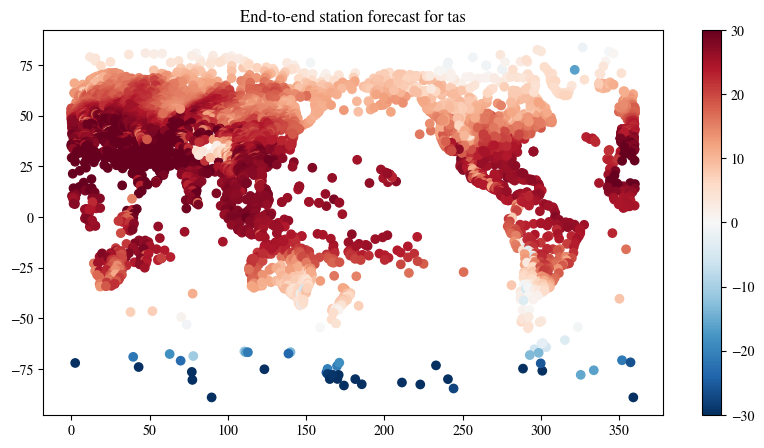

In [10]:
if station_forecast_unnorm is None:
    print("Skipping fine-tuned station forecast plot.")
else:
    fig = plt.figure(figsize=(10, 5))
    p = plt.scatter(
        data["downscaling"]["x_target"][0, 0, :].detach().cpu() * STATION_LON_LAT_SF,
        data["downscaling"]["x_target"][0, 1, :].detach().cpu() * STATION_LON_LAT_SF,
        c=station_forecast_unnorm[0, :],
        vmax=30,
        vmin=-30,
        cmap="RdBu_r",
    )
    plt.colorbar(p)
    plt.title(f"End-to-end station forecast for {local_forecast_var}")
    plt.show()
